erl 是一个强化学习（Reinforcement Learning, RL）训练框架，专门用于大语言模型（LLMs）。
- 在 verl 中，hf_processor 和 hf_tokenizer 是与 Hugging Face Transformers 库集成的工具，用于处理和标记化文本数据。这些工具在处理自然语言处理（NLP）任务时非常有用，尤其是在强化学习中，需要将文本数据转换为模型可以理解的格式。

verl 的项目结构清晰，模块划分合理，主要目录包括：

- verl/：核心代码目录，包含模型定义、训练器、工作者、工具和实用辅助模块。
  - models/：模型定义及权重加载相关代码，支持多种模型架构（如 Qwen2、Llama 等）。
  - single_controller/：单控制器模块，管理训练任务分发和 worker 协调。
  - workers/：工作者模块，包含不同训练和推理后端的实现，如 Megatron、FSDP、SGLang 推理相关代码。
  - tools/：工具和辅助功能模块。
  - third_party/：第三方库集成，如 vLLM 和 SGLang。
  - trainer/：训练器模块，包含强化学习算法实现及训练流程。
  - utils/：通用工具函数库。
- docs/：项目文档，包含进阶指南、API 说明、示例说明、常见问题、性能调优、入门教程等。
- examples/：示例代码，展示各种训练和推理场景。
- recipe/：具体 RL 算法实现示例，如 DAPO、SPPO、PRIME 等。
- tests/：测试代码。
- scripts/：辅助脚本，如模型合并、转换、诊断等。
- docker/：Docker 镜像相关文件。

VeRL 的源码通常位于 verl 目录下，主要包含以下几个关键子目录：
## verl/trainer (核心训练逻辑)
这是整个框架的“大脑”。
- main.py: 训练脚本的入口点。它解析配置，初始化 Ray 集群，并启动训练循环。
- ppo_trainer.py: 实现了 PPO（Proximal Policy Optimization）算法的主循环。它协调各个组件：
  - 收集数据（Generate）
  - 计算优势（Compute Advantages）
  - 更新模型（Update）
- config.py: 定义了训练所需的超参数配置类（通常基于 dataclass 或 omegaconf）。

## verl/single_controller (分布式控制层)
这是 VeRL 最具特色的部分，实现了论文中提到的“混合控制器”概念。
- base.py: 定义了控制器的抽象接口。
- ray_*: 包含基于 Ray 的具体实现（如 ray_critic.py, ray_actor.py）。
    - 作用：它将分散在不同 GPU 节点上的模型（Actor, Critic 等）封装成统一的“逻辑对象”。用户写代码时可以像调用本地函数一样调用远程的分布式模型（例如 self.actor.update()），而底层的通信（如 AllReduce, Broadcast）由 Ray 和 torch.distributed 自动处理。
    
## verl/protocol (数据结构与通信)
在强化学习中，Actor 产生的数据必须传递给 Critic 和 Reward 模型。
- proto.py: 定义了数据传输对象（Data Protocols）。
  - DataProto: 这是核心数据类，包含了 input_ids, attention_mask, responses, 以及计算出的 values, rewards, advantages 等。
  - 作用：确保数据在不同并行策略（如 Actor 用 TP+DP，Critic 用 DP）之间能够正确切分和传输。
  
## verl/models (模型封装与权重同步)
VeRL 需要管理多个模型副本（Actor, Critic, Reference, Reward）。
- transformers: 封装了 HuggingFace 模型，使其适应 VeRL 的训练流程。
- weight_sync.py: 非常关键的模块。
  - 在 PPO 中，Actor 更新后，通常需要将权重同步给 Reference 模型（或者定期同步）。
  - 在 Ray 架构下，这个模块负责高效地在不同进程组之间广播权重。
  
## verl/utils (工具库)
- checkpoint.py: 处理分布式检查点的保存与加载（通常使用 Sharded Checkpoints）。
- tokenizer.py: 处理分词逻辑。
- flops.py: 用于计算模型的理论 FLOPs，评估训练效率。


# 代码运行逻辑流

为了让你更好地理解代码结构，我们可以看一个典型的 PPO 训练步在代码中是如何流转的：
## 启动 (main.py):
- 初始化 Ray。
- 实例化 PPOTrainer。
## 数据收集 (ppo_trainer.py):
- 调用 self.actor.generate()。这实际上是通过 single_controller 调用了远程的 vLLM 或 HF 生成引擎。
- 收集生成的 responses。
## 计算与评估 (ppo_trainer.py):
- 将生成的数据分发给 Critic 和 Reward 模型。
- 调用 self.critic.compute_values() 和 self.reward.compute_reward()。
- 计算 GAE（Generalized Advantage Estimation）。
## 模型更新 (ppo_trainer.py):
- 进入训练循环（通常在一个 epoch 内多次更新）。
- 调用 self.actor.update() 和 self.critic.update()。
- 关键点：这里利用 PyTorch 的自动微分计算梯度，并通过 FSDP/Megatron 的后端进行梯度归约。
## 权重同步 (weight_sync.py):
- 如果需要，将更新后的 Actor 权重同步给 Reference 模型（用于计算 KL 散度）。


# 总结
VeRL 的代码结构设计哲学是 “解耦”：
- 算法与系统解耦：用户可以在 trainer 中专注于 PPO 的数学逻辑，而无需关心底层的 GPU 通信。
- 控制与计算解耦：通过 single_controller，实现了 Python 层面的集中控制与 C++/CUDA 层面的分布式计算的高效结合。

这种结构使得 VeRL 既适合学术研究人员修改算法（修改 trainer 即可），也适合工程师在生产环境中部署（调整 config 和并行策略即可）。

核心模块详解：

- <b>2.1 主入口模块（main_ppo.py）</b>

主入口模块负责初始化 Ray 集群和配置管理，采用 Hydra 框架进行灵活的配置管理。它把「资源管理、进程/角色划分、数据集与采样、奖励函数、多种分布式策略（FSDP / Megatron / vLLM）」这些零件拼在一起，然后交给 RayPPOTrainer 去跑。

- <b>2.2 TaskRunner 远程执行器</b>

作为 Ray 远程 actor，TaskRunner 封装了完整的训练逻辑。

- <b>2.3 Worker 角色系统</b>

verl 定义了多种 Worker 角色，每种角色对应特定的功能模块

In [1]:
from IPython.display import Image

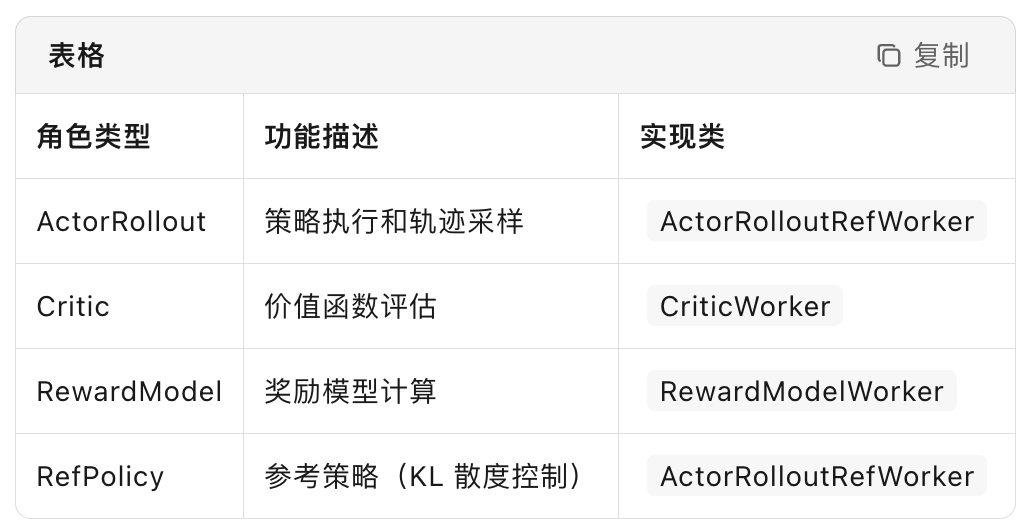

In [3]:
Image(filename='./image/role.png',width=600)

- <b>2.4 资源池管理（ResourcePoolManager）</b>

负责 GPU 资源的分配和调度。
- <b>2.5 奖励管理系统</b>

支持多种奖励计算方式。奖励管理器（RewardManager）是实现自定义奖励逻辑的核心组件，负责处理计算得到的奖励张量（reward_tensor）。
在 load_reward_manager 中，通过 get_reward_manager_cls 根据 config 中设置的 reward manager 名称获取对应的类，然后实例化并返回。


reward_fn 会传入 RayPPOTrainer，然后通过 reward_tensor, reward_extra_infos_dict = compute_reward(batch, self.reward_fn) 调用，在其中会直接调用 reward_result = reward_fn(data, return_dict=True)（即 AsyncRewardManager 的 __call__ 方法）

In [ ]:
from verl.workers.reward_manager import get_reward_manager_cls
reward_manager_name = config.reward_model.get("reward_manager", "naive")
reward_manager_cls = get_reward_manager_cls(reward_manager_name)
...
return reward_manager_cls(
    tokenizer=tokenizer,
    num_examine=num_examine,
    compute_score=final_compute_score,
    reward_fn_key=config.data.reward_fn_key,
    **reward_kwargs,
)

## KL 散度控制
verl 提供两种 KL 散度控制机制：
- KL 奖励惩罚
- KL 损失项

## 双裁剪 PPO
支持双裁剪 PPO 算法，防止策略过度更新

In [ ]:
# 在使用 verl 和 Hugging Face Transformers 之前，确保你已经安装了必要的依赖项：

pip install verl transformers

### hf_processor 是一个工具，用于加载和使用 Hugging Face 的预训练模型的处理器。
- 处理器通常包括分词器（tokenizer）、特征提取器（feature extractor）等，用于将原始数据转换为模型可以处理的格式。

### hf_tokenizer 是一个工具，用于加载和使用 Hugging Face 的预训练模型的分词器。
- 分词器将文本数据转换为模型可以理解的标记（tokens），并生成相应的输入 ID 和注意力掩码（attention mask）。

## 加载预训练模型的分词器

In [ ]:
from verl.utils import hf_tokenizer

# 加载预训练模型的分词器
tokenizer = hf_tokenizer("bert-base-uncased")

# 示例文本
text = "Hello, world!"

# 使用分词器对文本进行标记化
inputs = tokenizer(text, return_tensors="pt")

# 打印输入 ID 和注意力掩码
print(inputs["input_ids"])
print(inputs["attention_mask"])

## 加载预训练模型的处理器

In [ ]:
from verl.utils import hf_processor

# 加载预训练模型的处理器
processor = hf_processor("bert-base-uncased")

# 示例文本
text = "Hello, world!"

# 使用处理器对文本进行处理
inputs = processor(text, return_tensors="pt")

# 打印输入 ID 和注意力掩码
print(inputs["input_ids"])
print(inputs["attention_mask"])

verl（Volcano Engine Reinforcement Learning for LLMs）通过整合 FSDP 和 Megatron-LM，提供了从实验室原型到工业级部署的全链路解决方案。这种整合方案允许用户根据模型规模、硬件条件和任务需求灵活选择优化策略。
- FSDP：适用于中小规模模型（如 7B 以下），适合算法原型验证。它简单易用，支持任意 Hugging Face 模型。
- Megatron-LM：适用于大规模模型（如 70B+），在千亿级模型训练中表现出色。它提供了极致的并行效率和扩展性。

在大语言模型（LLM）的训练和推理中，FSDP（Fully Sharded Data Parallelism）和 Megatron-LM 是两种流行的分布式训练框架

verl 的统一接口设计使引擎切换变得异常简单。只需修改一个参数，即可在不同后端间无缝切换